In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split as holdout
from sklearn.neural_network import MLPRegressor
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('insurance.csv')
print(f'original df:\n{df}\n')

le = LabelEncoder()
le.fit(df.sex.drop_duplicates()) 
df.sex = le.transform(df.sex)
# smoker or not
le.fit(df.smoker.drop_duplicates()) 
df.smoker = le.transform(df.smoker)
#region
le.fit(df.region.drop_duplicates()) 
df.region = le.transform(df.region)
print(f'transformed df:\n{df}\n')

original df:
      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]

transformed df:
      age  sex     bmi  children  smoker  region      charges
0      19    0  27.900         0       1       3  16884.92400
1      18    1  3

In [4]:
print(df.duplicated().sum())
display(df[df.duplicated() == True])
print()
display(df[(df['age'] == 19) & (df['sex'] == 1) & (df['bmi'] == 30.59)])

1


,age,sex,bmi,children,smoker,region,charges
581,19,1,30.59,0,0,1,1639.5631


,age,sex,bmi,children,smoker,region,charges
195,19,1,30.59,0,0,1,1639.5631
581,19,1,30.59,0,0,1,1639.5631


In [5]:
smoker_val = 0
print(np.median(df[df['smoker'] == smoker_val]['charges']))
print(np.percentile(df[df['smoker'] == smoker_val]['charges'], [25, 50, 75]))

7345.4053
[ 3986.4387   7345.4053  11362.88705]


## EDA

In [14]:
## used TritonGPT to create basic EDA prints for the data

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from scipy import stats

df = pd.read_csv('insurance.csv')
print(f'raw df:\n{df}\n')

le = LabelEncoder()
le.fit(df.sex.drop_duplicates())
df.sex = le.transform(df.sex)
le.fit(df.smoker.drop_duplicates())
df.smoker = le.transform(df.smoker)
le.fit(df.region.drop_duplicates())
df.region = le.transform(df.region)

print(f'encoded df:\n{df}\n')

# ── 1. Basic Info ────────────────────────────────────────────────────────────
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes, "\n")

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(df.isnull().sum())
print(f"Total missing: {df.isnull().sum().sum()}\n")

print("=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
print(f"Number of duplicate rows: {df.duplicated().sum()}\n")

# ── 2. Descriptive Statistics ─────────────────────────────────────────────────
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
print(df.describe().round(3).to_string(), "\n")

# ── 3. Skewness & Kurtosis ────────────────────────────────────────────────────
print("=" * 60)
print("SKEWNESS & KURTOSIS (numeric features)")
print("=" * 60)
numeric_cols = ['age', 'bmi', 'charges']
for col in numeric_cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"  {col:<10} skew: {skew:+.4f}   kurtosis: {kurt:+.4f}")
print()

# ── 4. Percentiles for charges ────────────────────────────────────────────────
print("=" * 60)
print("CHARGES PERCENTILE BREAKDOWN")
print("=" * 60)
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    print(f"  {p:>3}th percentile: ${np.percentile(df['charges'], p):>12,.2f}")
print()

# ── 5. Categorical Value Counts ───────────────────────────────────────────────
print("=" * 60)
print("VALUE COUNTS — SEX  (0=female, 1=male)")
print("=" * 60)
print(df['sex'].value_counts().to_string(), "\n")

print("=" * 60)
print("VALUE COUNTS — SMOKER  (0=no, 1=yes)")
print("=" * 60)
print(df['smoker'].value_counts().to_string(), "\n")

print("=" * 60)
print("VALUE COUNTS — REGION  (0=NE, 1=NW, 2=SE, 3=SW)")
print("=" * 60)
print(df['region'].value_counts().to_string(), "\n")

print("=" * 60)
print("VALUE COUNTS — CHILDREN")
print("=" * 60)
print(df['children'].value_counts().sort_index().to_string(), "\n")

# ── 6. Charges by Categorical Groups ─────────────────────────────────────────
print("=" * 60)
print("CHARGES BY SMOKER STATUS")
print("=" * 60)
print(df.groupby('smoker')['charges'].agg(['mean', 'median', 'std', 'min', 'max']).round(2).to_string(), "\n")

print("=" * 60)
print("CHARGES BY SEX")
print("=" * 60)
print(df.groupby('sex')['charges'].agg(['mean', 'median', 'std', 'min', 'max']).round(2).to_string(), "\n")

print("=" * 60)
print("CHARGES BY REGION")
print("=" * 60)
print(df.groupby('region')['charges'].agg(['mean', 'median', 'std', 'min', 'max']).round(2).to_string(), "\n")

print("=" * 60)
print("CHARGES BY NUMBER OF CHILDREN")
print("=" * 60)
print(df.groupby('children')['charges'].agg(['mean', 'median', 'std', 'count']).round(2).to_string(), "\n")

# ── 7. Smoker proportions by sex & region ────────────────────────────────────
print("=" * 60)
print("SMOKER RATE BY SEX")
print("=" * 60)
print(df.groupby('sex')['smoker'].mean().round(4).to_string(), "\n")

print("=" * 60)
print("SMOKER RATE BY REGION")
print("=" * 60)
print(df.groupby('region')['smoker'].mean().round(4).to_string(), "\n")

# ── 8. Correlation ────────────────────────────────────────────────────────────
print("=" * 60)
print("PEARSON CORRELATION WITH CHARGES")
print("=" * 60)
print(df.corr(numeric_only=True)['charges'].sort_values(ascending=False).round(4).to_string(), "\n")

print("=" * 60)
print("SPEARMAN CORRELATION WITH CHARGES")
print("=" * 60)
print(df.corr(method='spearman', numeric_only=True)['charges'].sort_values(ascending=False).round(4).to_string(), "\n")

print("=" * 60)
print("FULL SPEARMAN CORRELATION MATRIX")
print("=" * 60)
print(df.corr(method='spearman', numeric_only=True).round(2).to_string(), "\n")

# ── 9. Statistical Tests ──────────────────────────────────────────────────────
print("=" * 60)
print("T-TEST: CHARGES — SMOKER vs NON-SMOKER")
print("=" * 60)
smokers    = df[df['smoker'] == 1]['charges']
nonsmokers = df[df['smoker'] == 0]['charges']
t_stat, p_val = stats.ttest_ind(smokers, nonsmokers)
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value:     {p_val:.4e}")
print(f"  Significant (p<0.05): {p_val < 0.05}\n")

print("=" * 60)
print("T-TEST: CHARGES — MALE vs FEMALE")
print("=" * 60)
males   = df[df['sex'] == 1]['charges']
females = df[df['sex'] == 0]['charges']
t_stat, p_val = stats.ttest_ind(males, females)
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value:     {p_val:.4e}")
print(f"  Significant (p<0.05): {p_val < 0.05}\n")

print("=" * 60)
print("ONE-WAY ANOVA: CHARGES ACROSS REGIONS")
print("=" * 60)
region_groups = [df[df['region'] == r]['charges'] for r in df['region'].unique()]
f_stat, p_val = stats.f_oneway(*region_groups)
print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value:     {p_val:.4e}")
print(f"  Significant (p<0.05): {p_val < 0.05}\n")

# ── 10. BMI Categorisation ────────────────────────────────────────────────────
print("=" * 60)
print("BMI CATEGORY DISTRIBUTION")
print("=" * 60)
bins   = [0, 18.5, 25, 30, 100]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df['bmi_category'] = pd.cut(df['bmi'], bins=bins, labels=labels)
print(df['bmi_category'].value_counts().sort_index().to_string(), "\n")

print("=" * 60)
print("MEAN CHARGES BY BMI CATEGORY")
print("=" * 60)
print(df.groupby('bmi_category', observed=True)['charges'].agg(['mean', 'median', 'count']).round(2).to_string(), "\n")

# ── 11. Age Binning ───────────────────────────────────────────────────────────
print("=" * 60)
print("MEAN CHARGES BY AGE GROUP")
print("=" * 60)
df['age_group'] = pd.cut(df['age'], bins=[17, 30, 45, 60, 70], labels=['18-30', '31-45', '46-60', '61+'])
print(df.groupby('age_group', observed=True)['charges'].agg(['mean', 'median', 'count']).round(2).to_string(), "\n")

# ── 12. High-cost outlier analysis ───────────────────────────────────────────
print("=" * 60)
print("HIGH-COST OUTLIERS (charges > 99th percentile)")
print("=" * 60)
threshold = np.percentile(df['charges'], 99)
outliers  = df[df['charges'] > threshold]
print(f"  Threshold: ${threshold:,.2f}")
print(f"  Count:     {len(outliers)}")
print(outliers[['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']].to_string(), "\n")

raw df:
      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]

encoded df:
      age  sex     bmi  children  smoker  region      charges
0      19    0  27.900         0       1       3  16884.92400
1      18    1  33.770    

$$\text{charges} \in [1121, 63770]$$

DATASET OVERVIEW:
Shape: (1338, 7)
Missing vals: 0
Duplicates: 1

Descriptive stats:
           age      sex      bmi  children  smoker   region   charges
count  1338.00  1338.00  1338.00   1338.00  1338.0  1338.00   1338.00
mean     39.21     0.51    30.66      1.09     0.2     1.52  13270.42
std      14.05     0.50     6.10      1.21     0.4     1.10  12110.01
min      18.00     0.00    15.96      0.00     0.0     0.00   1121.87
25%      27.00     0.00    26.30      0.00     0.0     1.00   4740.29
50%      39.00     1.00    30.40      1.00     0.0     2.00   9382.03
75%      51.00     1.00    34.69      2.00     0.0     2.00  16639.91
max      64.00     1.00    53.13      5.00     1.0     3.00  63770.43


Distribution moments (numeric cols):
age: | skew=+0.056 <-> kurt=-1.245
bmi: | skew=+0.284 <-> kurt=-0.055
charges: | skew=+1.514 <-> kurt=+1.596


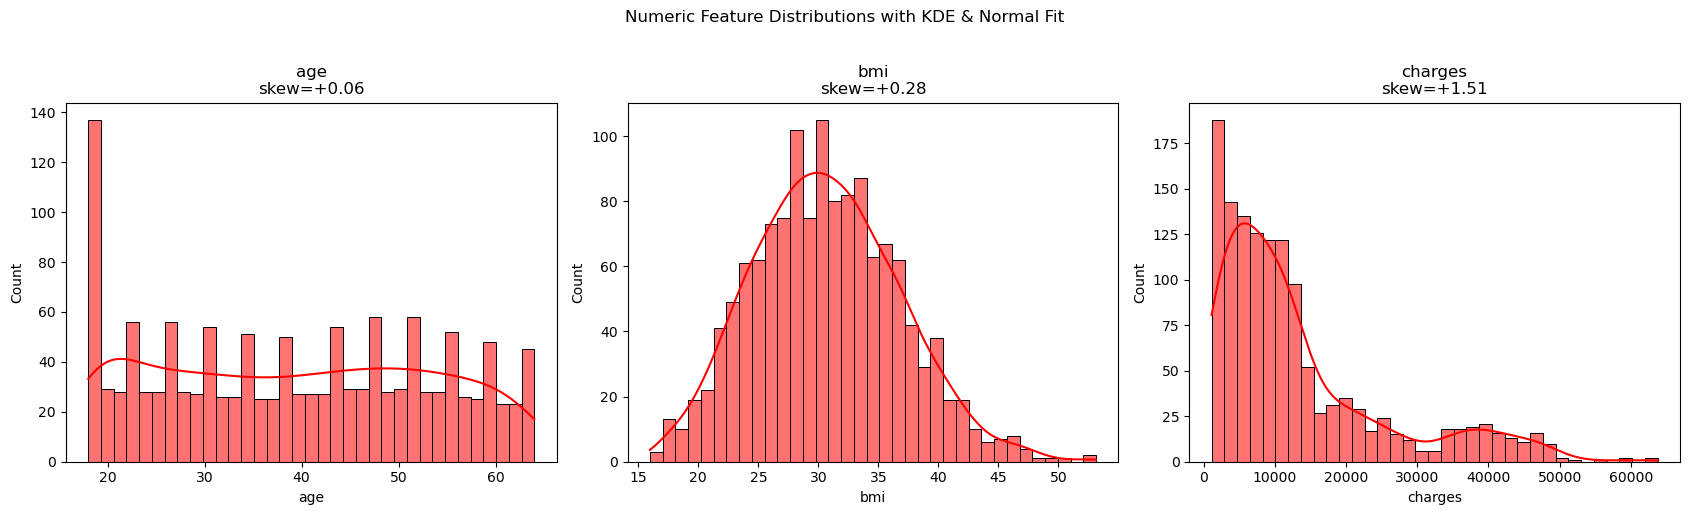

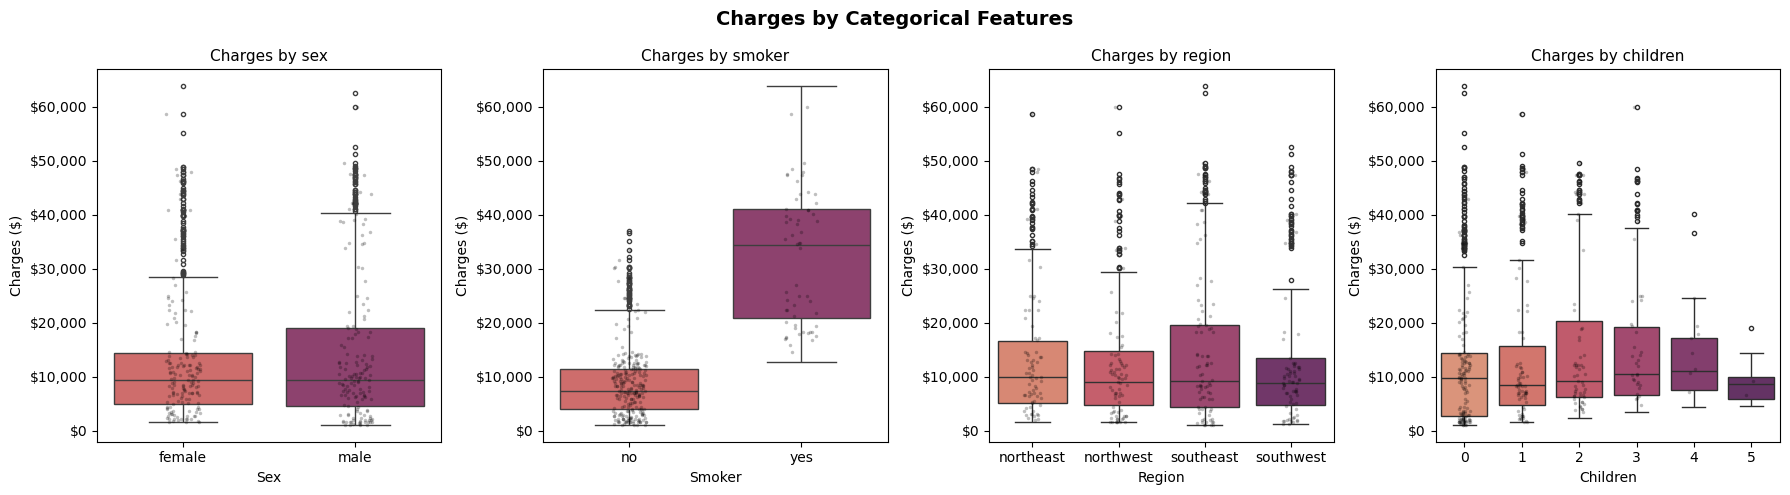

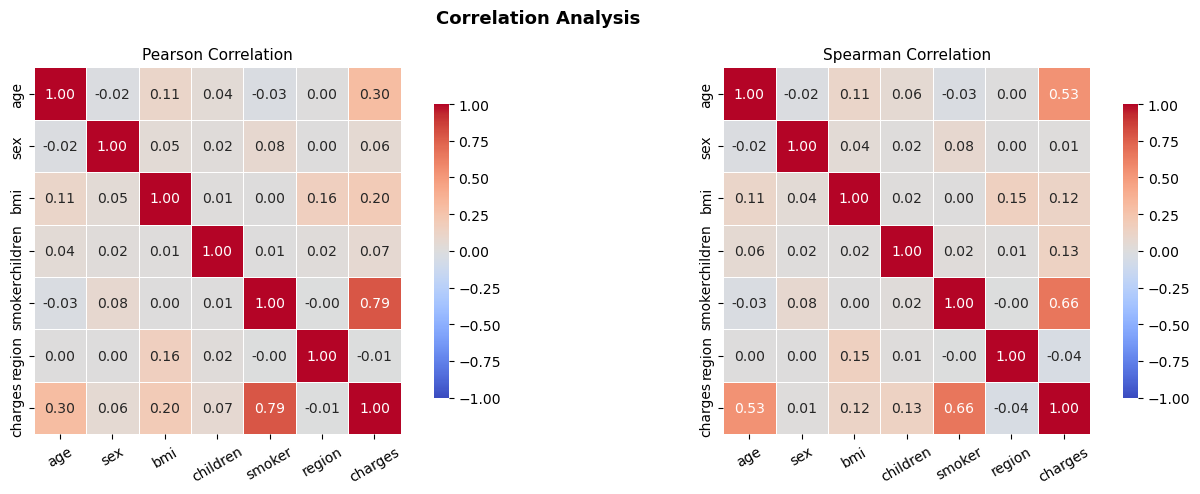

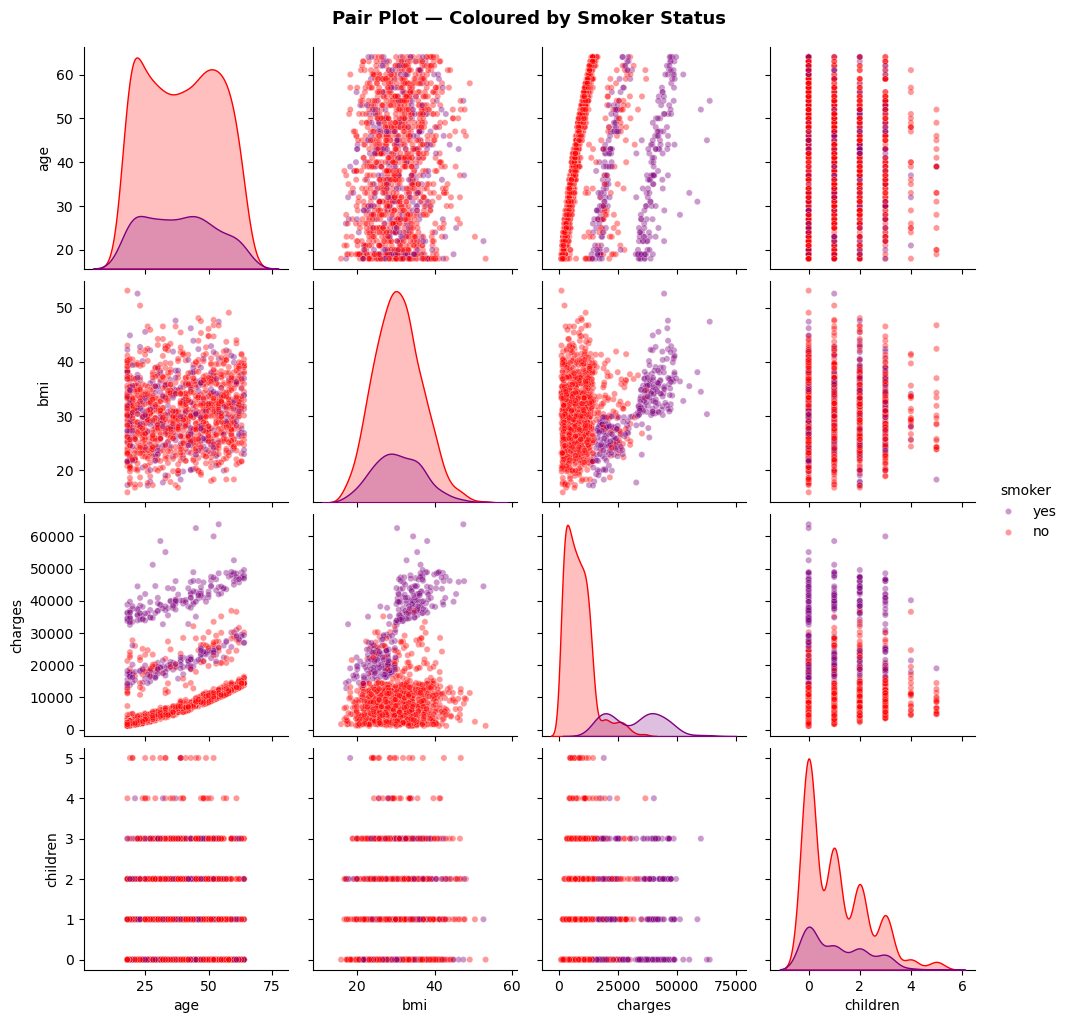

In [6]:
# Advanced Visual EDA & Preprocessing

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, shapiro, pearsonr
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('insurance.csv')

le = LabelEncoder()
le.fit(df.sex.drop_duplicates()) 
df.sex = le.transform(df.sex)
le.fit(df.smoker.drop_duplicates()) 
df.smoker = le.transform(df.smoker)
le.fit(df.region.drop_duplicates()) 
df.region = le.transform(df.region)

REGION_MAP = {0:"northeast", 1:"northwest", 2:"southeast", 3:"southwest"}
SEX_MAP = {0:"female", 1:"male"}
SMOKER_MAP = {0:"no", 1:"yes"}
CHILDREN_MAP = {0:"0",1:"1",2:"2",3:"3",4:"4",5:"5"}

NUM_COLS = ["age","bmi","charges"]
CAT_COLS = ["sex","children","smoker","region"]
TARGET = "charges"

# Dataset Overview:
print("DATASET OVERVIEW:")
print(f"Shape: {df.shape}")
print(f"Missing vals: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}\n")
print(f"Descriptive stats:\n{df.describe().round(2)}\n")

# distribution moments
print("\nDistribution moments (numeric cols):")
for c in NUM_COLS:
    print(f"{c}: | skew={skew(df[c]):+.3f} <-> kurt={kurtosis(df[c]):+.3f}")

# Numeric Distributions + KDE:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Numeric Feature Distributions with KDE & Normal Fit", y=1.02)

for ax, col in zip(axes, NUM_COLS):
    data = df[col]
    sns.histplot(data,bins=35,kde=True,color='red',alpha=0.55,edgecolor="black",ax=ax)
    ax.set_title(f"{col}\nskew={skew(data):+.2f}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

# Box-plots + Swarm (categorical vs charges):
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Charges by Categorical Features", fontsize=14, fontweight="bold")
cat_plot_map = {"sex": SEX_MAP, "smoker": SMOKER_MAP, "region": REGION_MAP, "children": CHILDREN_MAP}

for ax, col in zip(axes, ["sex","smoker","region","children"]):
    temp = df.copy()
    temp[col] = temp[col].map(cat_plot_map[col])
    order = sorted(temp[col].unique())
    sns.boxplot(data=temp, x=col, y="charges", order=order, palette='flare', ax=ax, fliersize=3)
    sns.stripplot(data=temp.sample(min(300, len(temp)), random_state=1), x=col, y="charges", order=order, color="black", alpha=0.25, size=2.5, ax=ax, jitter=True)
    ax.set_title(f"Charges by {col}", fontsize=11)
    ax.set_xlabel(col.capitalize()); ax.set_ylabel("Charges ($)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

# Correlation Heatmap:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Correlation Analysis", fontsize=13, fontweight="bold")

corr_pearson  = df.corr(method="pearson")
corr_spearman = df.corr(method="spearman")
# mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

for ax, corr, title in zip(axes,
                            [corr_pearson, corr_spearman],
                            ["Pearson Correlation", "Spearman Correlation"]):
    sns.heatmap(corr, annot=True, fmt=".2f", center=0,
                cmap="coolwarm", linewidths=0.5, ax=ax,
                vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# Scatter Matrix (Pair Plot):
temp = df.copy()
temp["smoker"] = temp["smoker"].map(SMOKER_MAP)
g = sns.pairplot(temp[["age","bmi","charges","children","smoker"]],
                 hue="smoker", palette={"no": 'red', "yes": 'purple'},
                 diag_kind="kde", plot_kws={"alpha": 0.4, "s": 20},
                 diag_kws={"fill": True})
g.figure.suptitle("Pair Plot — Coloured by Smoker Status",
                  fontsize=13, fontweight="bold", y=1.02)
plt.show()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr
import warnings
warnings.filterwarnings('ignore')

def section(title):
    print(f"{title}:\n")

section("Loading Data:") 
df_raw = pd.read_csv('insurance.csv')
print(f"df_raw:\n{df_raw}\n")

section("Missing Values & Duplicates:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
df = df_raw.drop_duplicates().reset_index(drop=True)

section("Label Encoding:")
le = LabelEncoder()
cat_cols = ['sex', 'smoker', 'region']
encoding_map = {}

for col in cat_cols:
    le.fit(df[col])
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    df[col] = le.transform(df[col])
    print(f"  {col}: {encoding_map[col]}")

num_cols = ['age', 'bmi', 'children', 'charges']
all_cols = num_cols + cat_cols

print(f"\nEncoded df head:\n{df.head()}")
print(f"\nDescribe:\n{df.describe()}")


section("Outlier Detection (IQR + Z-Score):")
outlier_summary = {}
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    iqr_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    z_out   = (np.abs(stats.zscore(df[col])) > 3).sum()
    outlier_summary[col] = {'IQR_outliers': iqr_out, 'Z_outliers': z_out,
                             'lower': lower, 'upper': upper}
    print(f"{col}: IQR outliers = {iqr_out:4d} <-> Z-outliers = {z_out:4d} -> bounds=[{lower:.2f}, {upper:.2f}]")


section("Skewness & Kurtosis")
for col in num_cols:
    sk = df[col].skew()
    ku = df[col].kurt()
    flag = "Highly Skewed" if abs(sk) > 1 else "fine"
    print(f"{col}: skew={sk:7.3f} <-> kurtosis={ku:7.3f} [{flag}]")


section("Correlation Analysis")
corr = df.corr(method='spearman')
print(f"\nCorrelation with 'charges':\n{corr['charges'].sort_values(ascending=False)}")


section("Other Preprocessing")
df_proc = df.copy()
# Feature Engineering:
df_proc['bmi_category'] = pd.cut(df_proc['bmi'],bins=[0, 18.5, 24.9, 29.9, 100], labels=[0, 1, 2, 3]).astype(int)
df_proc['age_group'] = pd.cut(df_proc['age'], bins=[17, 30, 45, 60, 65], labels=[0, 1, 2, 3]).astype(int)
df_proc['age2'] = df_proc['age']**2
df_proc['obese'] = (df_proc['bmi'] >= 30).astype(int)
df_proc['smoker_age'] = df_proc['smoker'] * df_proc['age']
df_proc['smoker_bmi'] = df_proc['smoker'] * df_proc['bmi']
df_proc['smoker_obese'] = (df_proc['smoker'] * (df_proc['obese'])).astype(int)
df_proc['charges_log'] = np.log1p(df_proc['charges'])
df_proc['bmi_age_interact'] = df_proc['bmi'] * df_proc['age']
df_proc['risk_score'] = df_proc['smoker'] * 3 + df_proc['bmi_category'] + (df_proc['age'] // 10)
# Scaling comparisons:
scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()
scaler_rob = RobustScaler()
scaler_pt = PowerTransformer(method='yeo-johnson')
scale_targets = ['age', 'bmi', 'charges']
df_std = pd.DataFrame(scaler_std.fit_transform(df_proc[scale_targets]),  columns=scale_targets)
df_mm  = pd.DataFrame(scaler_mm.fit_transform(df_proc[scale_targets]),   columns=scale_targets)
df_rob = pd.DataFrame(scaler_rob.fit_transform(df_proc[scale_targets]),  columns=scale_targets)
df_pt  = pd.DataFrame(scaler_pt.fit_transform(df_proc[scale_targets]),   columns=scale_targets)
print(f"StandardScaler charges: mean={df_std['charges'].mean():.4f}, std={df_std['charges'].std():.4f}")
print(f"MinMaxScaler charges: min={df_mm['charges'].min():.4f},  max={df_mm['charges'].max():.4f}")
print(f"RobustScaler charges: mean={df_rob['charges'].mean():.4f}")
print(f"PowerTransform charges: skew={df_pt['charges'].skew():.4f}")
# PCA:
print("\n  [7c] PCA")
pca_features = ['age', 'bmi', 'children', 'charges_log', 'bmi_age_interact', 'risk_score']
X_scaled_pca = scaler_std.fit_transform(df_proc[pca_features])
pca = PCA(n_components=len(pca_features))
pca.fit(X_scaled_pca)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)
print(f"Explained variance per component: {[f'{v:.3f}' for v in explained]}")
print(f"Cumulative: {[f'{v:.3f}' for v in cumulative]}")
n_components_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")

# Final processed df:
df_final = df_proc.copy()
df_final[['age_scaled', 'bmi_scaled', 'charges_scaled']] = df_rob[scale_targets].values
print(f"\nFinal processed shape: {df_final.shape}")
print(f"Final columns: {df_final.columns.tolist()}")
display(df_final)

Loading Data::

df_raw:
      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]

Missing Values & Duplicates::

Label Encoding::

  sex: {'female': np.int64(0), 'male': np.int64(1)}
  smoker: {'no': np.int64(0), 'yes': np.int64

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,age2,obese,smoker_age,smoker_bmi,smoker_obese,charges_log,bmi_age_interact,risk_score,age_scaled,bmi_scaled,charges_scaled
0,19,0,27.900,0,1,3,16884.92400,2,0,361,0,19,27.90,0,9.734236,530.100,6,-0.833333,-0.297265,0.629546
1,18,1,33.770,1,0,2,1725.55230,3,0,324,1,0,0.00,0,7.453882,607.860,4,-0.875000,0.400713,-0.643134
2,28,1,33.000,3,0,2,4449.46200,3,0,784,1,0,0.00,0,8.400763,924.000,5,-0.458333,0.309156,-0.414453
3,33,1,22.705,0,0,1,21984.47061,1,1,1089,0,0,0.00,0,9.998137,749.265,4,-0.250000,-0.914982,1.057671
4,32,1,28.880,0,0,1,3866.85520,2,1,1024,0,0,0.00,0,8.260455,924.160,5,-0.291667,-0.180737,-0.463364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332,50,1,30.970,3,0,1,10600.54830,3,2,2500,1,0,0.00,0,9.268755,1548.500,8,0.458333,0.067776,0.101952
1333,18,0,31.920,0,0,0,2205.98080,3,0,324,1,0,0.00,0,7.699381,574.560,4,-0.875000,0.180737,-0.602800
1334,18,0,36.850,0,0,2,1629.83350,3,0,324,1,0,0.00,0,7.396847,663.300,4,-0.875000,0.766944,-0.651170
1335,21,0,25.800,0,0,3,2007.94500,2,0,441,0,0,0.00,0,7.605365,541.800,4,-0.750000,-0.546968,-0.619426


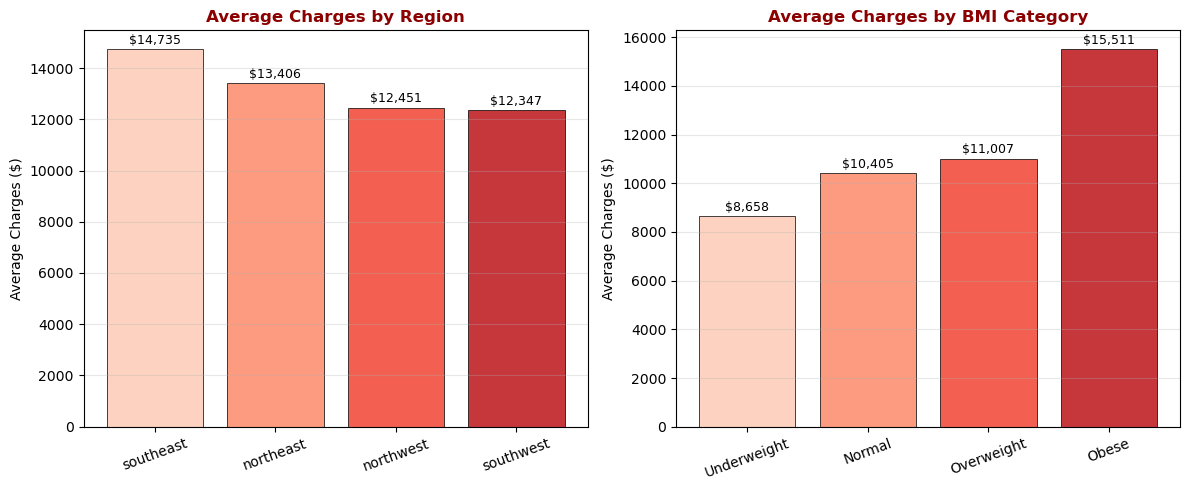

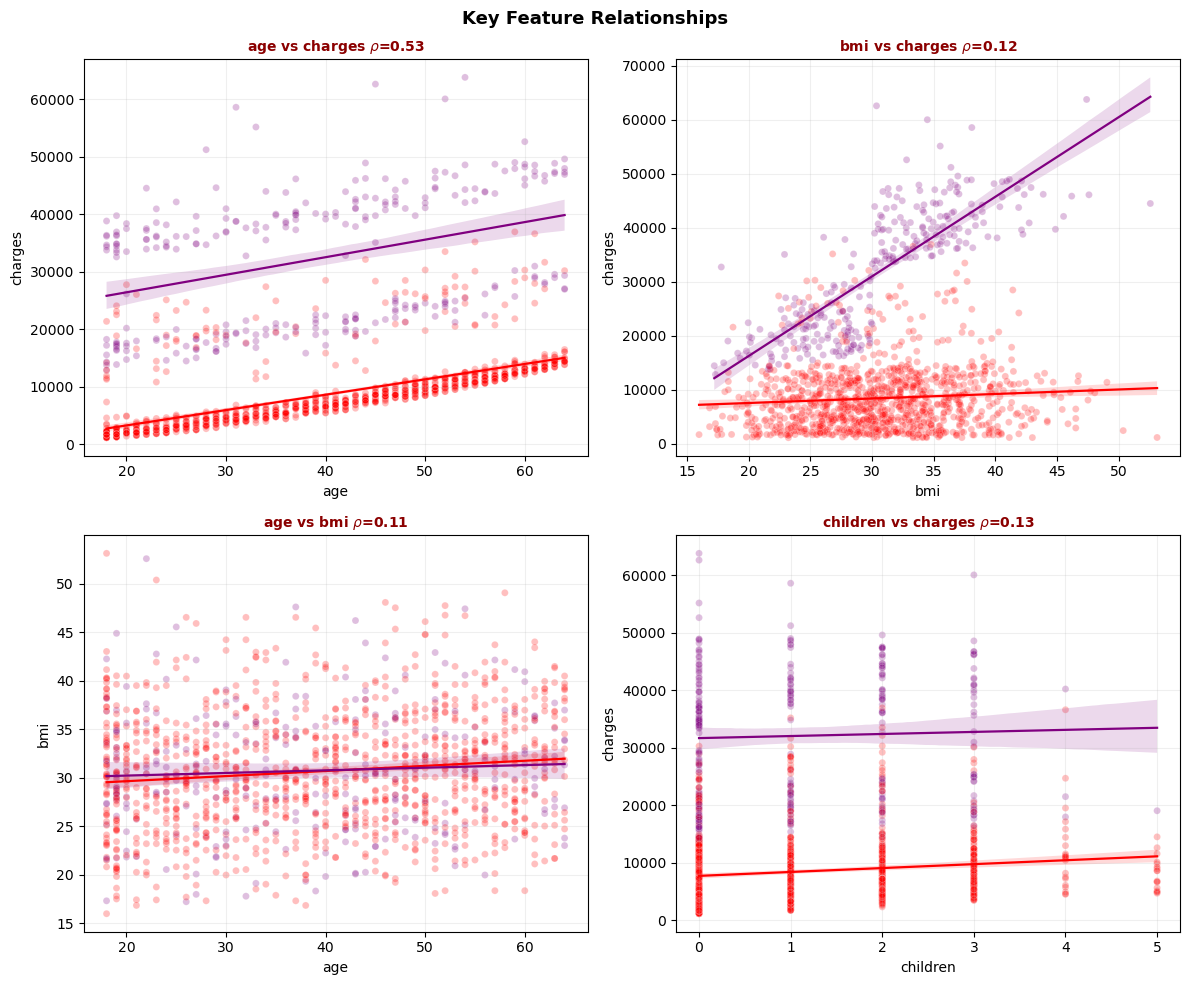

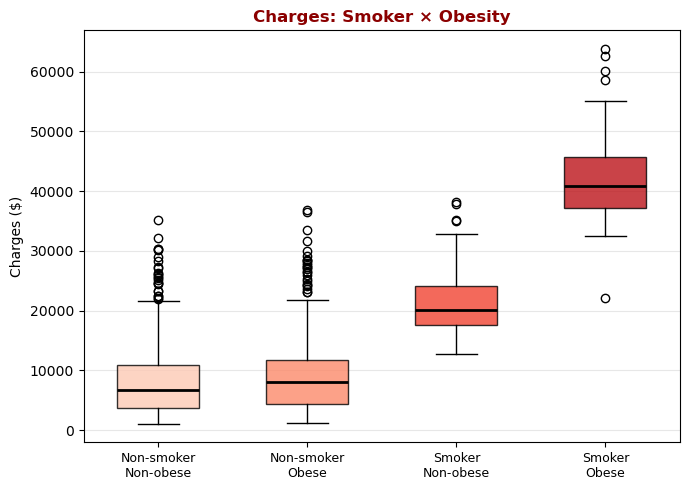

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Average Charges by Region:
ax = axes[0]

region_labels = REGION_MAP
region_means = df.groupby('region')['charges'].mean().sort_values(ascending=False)
palette = sns.color_palette("Reds", len(region_means))
bars = ax.bar(range(len(region_means)), region_means.values, color=palette, alpha=0.85, edgecolor='black', linewidth=0.6)
ax.set_xticks(range(len(region_means)))
ax.set_xticklabels([region_labels[r] for r in region_means.index], rotation=20, fontsize=10)
ax.set_title("Average Charges by Region", fontsize=12, fontweight="bold", color="darkred")
ax.set_ylabel("Average Charges ($)")
for bar, val in zip(bars, region_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f"${val:,.0f}", ha="center", va="bottom", fontsize=9)
ax.grid(axis='y', alpha=0.3)


# Average Charges by BMI Category:
ax = axes[1]
bmi_labels = ['Underweight','Normal','Overweight','Obese']
bmi_means = df_proc.groupby('bmi_category')['charges'].mean()
palette = sns.color_palette("Reds", len(bmi_means))
bars = ax.bar(range(len(bmi_means)), bmi_means.values, color=palette, alpha=0.85, edgecolor='black', linewidth=0.6)

ax.set_xticks(range(len(bmi_means)))
ax.set_xticklabels(bmi_labels, rotation=20, fontsize=10)
ax.set_title("Average Charges by BMI Category", fontsize=12, fontweight="bold", color="darkred")
ax.set_ylabel("Average Charges ($)")

for bar, val in zip(bars, bmi_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f"${val:,.0f}", ha="center", va="bottom", fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Scatter Matrix of 4 Key Relationships:
pairs = [('age', 'charges'), ('bmi', 'charges'), ('age', 'bmi'), ('children', 'charges')]
fig, axes = plt.subplots(2, 2, figsize=(12,10))
fig.suptitle("Key Feature Relationships", fontsize=13, fontweight="bold")
axes = axes.flatten()
palette = {0: "red", 1: "purple"}
for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(x=x, y=y, hue="smoker", data=df, palette=palette, alpha=0.25, s=25, legend=False, ax=ax)

    for smoker_val, color in palette.items():
        sns.regplot(x=df[df["smoker"] == smoker_val][x], y=df[df["smoker"] == smoker_val][y], scatter=False, ax=ax, color=color, line_kws={"linestyle": "-", "linewidth": 1.6} )
    r, p = stats.spearmanr(df[x], df[y])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title( fr"{x} vs {y} $\rho$={r:.2f}", fontsize=10, fontweight="bold", color="darkred" )
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Charges: Smoker × Obesity
fig, ax = plt.subplots(figsize=(7,5))

groups = [df_proc[(df_proc['smoker']==0) & (df_proc['bmi']<30)]['charges'],
          df_proc[(df_proc['smoker']==0) & (df_proc['bmi']>=30)]['charges'],
          df_proc[(df_proc['smoker']==1) & (df_proc['bmi']<30)]['charges'],
          df_proc[(df_proc['smoker']==1) & (df_proc['bmi']>=30)]['charges']]

labels = ['Non-smoker\nNon-obese',
          'Non-smoker\nObese',
          'Smoker\nNon-obese',
          'Smoker\nObese']

palette = sns.color_palette("Reds", len(groups))
box = ax.boxplot(groups, patch_artist=True, widths=0.55, showfliers=True)

for patch, color in zip(box['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
    patch.set_edgecolor('black')

for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax.set_xticks(range(1, len(labels)+1))
ax.set_xticklabels(labels, fontsize=9)
ax.set_title("Charges: Smoker × Obesity", fontsize=12, fontweight="bold", color="darkred")
ax.set_ylabel("Charges ($)")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
df_final

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,age2,obese,smoker_age,smoker_bmi,smoker_obese,charges_log,bmi_age_interact,risk_score,age_scaled,bmi_scaled,charges_scaled
0,19,0,27.900,0,1,3,16884.92400,2,0,361,0,19,27.90,0,9.734236,530.100,6,-0.833333,-0.297265,0.629546
1,18,1,33.770,1,0,2,1725.55230,3,0,324,1,0,0.00,0,7.453882,607.860,4,-0.875000,0.400713,-0.643134
2,28,1,33.000,3,0,2,4449.46200,3,0,784,1,0,0.00,0,8.400763,924.000,5,-0.458333,0.309156,-0.414453
3,33,1,22.705,0,0,1,21984.47061,1,1,1089,0,0,0.00,0,9.998137,749.265,4,-0.250000,-0.914982,1.057671
4,32,1,28.880,0,0,1,3866.85520,2,1,1024,0,0,0.00,0,8.260455,924.160,5,-0.291667,-0.180737,-0.463364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332,50,1,30.970,3,0,1,10600.54830,3,2,2500,1,0,0.00,0,9.268755,1548.500,8,0.458333,0.067776,0.101952
1333,18,0,31.920,0,0,0,2205.98080,3,0,324,1,0,0.00,0,7.699381,574.560,4,-0.875000,0.180737,-0.602800
1334,18,0,36.850,0,0,2,1629.83350,3,0,324,1,0,0.00,0,7.396847,663.300,4,-0.875000,0.766944,-0.651170
1335,21,0,25.800,0,0,3,2007.94500,2,0,441,0,0,0.00,0,7.605365,541.800,4,-0.750000,-0.546968,-0.619426


In [10]:
df_final.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'bmi_category', 'age_group', 'age2', 'obese', 'smoker_age',
       'smoker_bmi', 'smoker_obese', 'charges_log', 'bmi_age_interact',
       'risk_score', 'age_scaled', 'bmi_scaled', 'charges_scaled'],
      dtype='object')

In [11]:
df_final.to_csv('final_df.csv')

Given the code below, I want you to write up the following section "4. Modeling Methodology". In 4.1, you will write up the Baseline Ordinary Least Squares (OLS) by writing out the Mathematical Formulation, Assumptions, Estimation and Software, and Expected Limitations. In 4.2, you will write up the Log-Linear OLS by writing out the Motivation for Log Transformation, Mathematical Formulation, Assumptions, Back-Transformation and Bias Correction, Expected Improvements Over Baseline. In 4.3, you will write up the Linear Mixed-Effects Model (LME) by writing out the Motivation, Mathematical Formulation, Assumptions, Estimation, Model Comparison with OLS. In 4.4, you will write up the Random Forest (Ensemble Learning) by writing out the Motivation, Algorithm Overview, Assumptions, Hyperparameter Tuning, Feature Importance 

Data Preparation

Shape: (1337, 20)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'bmi_category', 'age_group', 'age2', 'obese', 'smoker_age', 'smoker_bmi', 'smoker_obese', 'charges_log', 'bmi_age_interact', 'risk_score', 'age_scaled', 'bmi_scaled', 'charges_scaled']
DataFrame:
      age  sex     bmi  children  smoker  region      charges  bmi_category  \
0      19    0  27.900         0       1       3  16884.92400             2   
1      18    1  33.770         1       0       2   1725.55230             3   
2      28    1  33.000         3       0       2   4449.46200             3   
3      33    1  22.705         0       0       1  21984.47061             1   
4      32    1  28.880         0       0       1   3866.85520             2   
...   ...  ...     ...       ...     ...     ...          ...           ...   
1332   50    1  30.970         3       0       1  10600.54830             3   
1333   18    0  31.920         0       0       0   2205.98080 

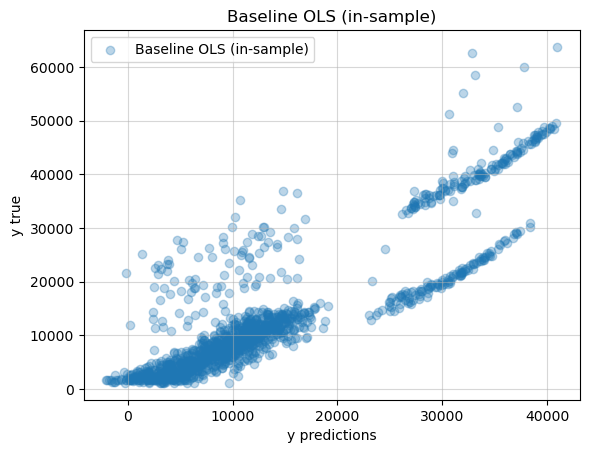

Baseline OLS (in-sample) -> R^2=0.7506 & RMSE=6,045.99 & MAE=4,175.08 & MAPE=42.24%

MODEL 2 — LOG-LINEAR OLS (log target + smoker interactions)

                            OLS Regression Results                            
Dep. Variable:            charges_log   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     594.2
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:54:07   Log-Likelihood:                -592.74
No. Observations:                1337   AIC:                             1209.
Df Residuals:                    1325   BIC:                             1272.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0

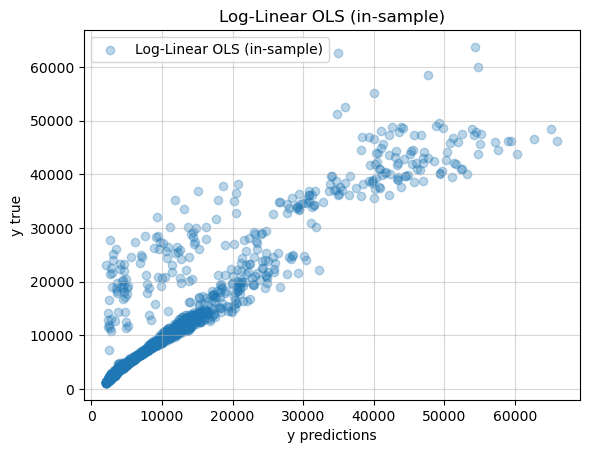

Log-Linear OLS (in-sample) -> R^2=0.8333 & RMSE=4,942.40 & MAE=2,481.70 & MAPE=17.51%


Residuals skew (log model) : 3.2331(vs baseline: 1.2062)
MODEL 3 — LINEAR MIXED-EFFECTS (region as random intercept)

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: charges_log
No. Observations: 1337    Method:             REML       
No. Groups:       4       Scale:              0.1434     
Min. group size:  324     Log-Likelihood:     -644.6568  
Max. group size:  364     Converged:          Yes        
Mean group size:  334.2                                  
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
const          6.741    0.126  53.367 0.000  6.494  6.989
age            0.060    0.005  11.706 0.000  0.050  0.070
age2          -0.000    0.000  -3.629 0.000 -0.000 -0.000
sex           -0.086    0.021  -4.117 0.000 -0.127

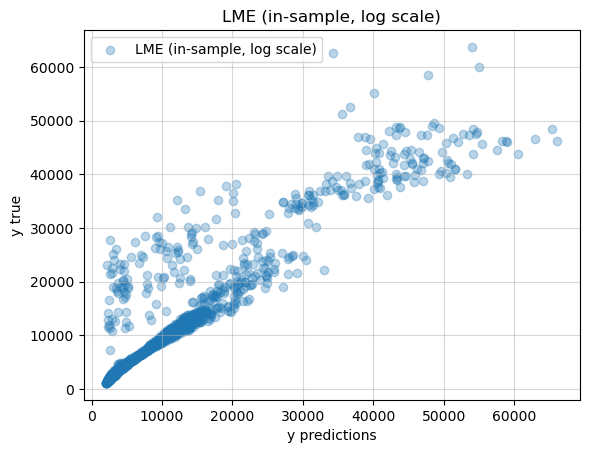

LME (in-sample, log scale) -> R^2=0.8336 & RMSE=4,938.00 & MAE=2,467.89 & MAPE=17.39%


Random Forest

  Feature importances:
    smoker_bmi     0.284
    age            0.208
    age2           0.172
    smoker_age     0.097
    bmi            0.085
    smoker         0.058
    children       0.051
    region         0.025
    sex            0.012
    obese          0.005
    smoker_obese   0.002

  R² Train ($ scale):  0.957
  R² Test  ($ scale):  0.897

  CV R² scores:  [0.763 0.827 0.751 0.78  0.781]
  Mean CV R²:    0.781
  Std  CV R²:    0.026

len datapoints: 268


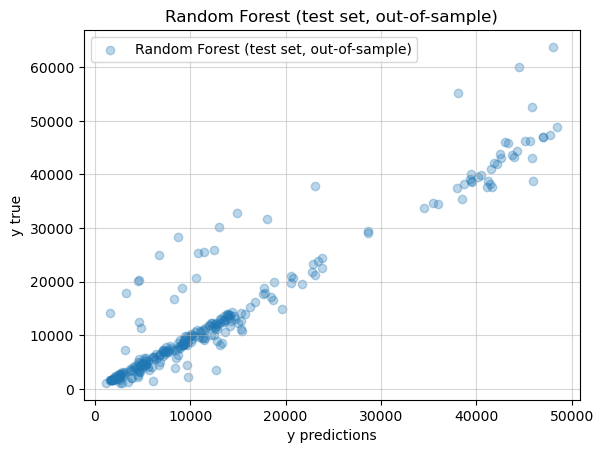

Random Forest (test set, out-of-sample) -> R^2=0.8971 & RMSE=4,347.96 & MAE=2,060.26 & MAPE=20.41%

MODEL COMPARISON SUMMARY


Model                                             R²       RMSE        MAE     MAPE
1. Baseline OLS (raw charges)                 0.7506      6,046      4,175   42.24%
2. Log-Linear OLS (enriched + smoker IA)      0.8333      4,942      2,482   17.51%
3. LME  (random region intercept)             0.8336      4,938      2,468   17.39%
4. Random Forest (test set)                   0.8971      4,348      2,060   20.41%


In [17]:
# Regression Modeling Pipeline
# 1. Baseline OLS (statsmodels OLS, raw charges, base features)
# 2. Log-Linear OLS (statsmodels OLS, log target + smoker interactions)
# 3. Linear Mixed-Effects (statsmodels MixedLM, region as random intercept)
# 4. Random Forest Model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

ACCENT, ACCENT2, ACCENT3, ACCENT4 = 'red', 'blue', 'green', 'purple'
PALETTE = ['red', 'blue', 'green', 'purple', 'orange', 'olive']

def divider(title, width=64):
    print(f"{title}\n")

def metrics(y_true, y_pred, label='', log_target=False, plot=False):
    if log_target:
        y_pred, y_true = np.exp(y_pred), np.exp(y_true)
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\nlen datapoints: {len(y_pred)}")
    if plot:
        plt.figure()
        plt.scatter(y_pred, y_true, alpha=0.3, label=label)
        plt.xlabel('y predictions')
        plt.ylabel('y true')
        plt.title(label)
        plt.legend()
        plt.grid(alpha=0.5)
        plt.show()
    print(f"{label} -> R^2={r2:.4f} & RMSE={rmse:,.2f} & MAE={mae:,.2f} & MAPE={mape:.2f}%\n")
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}


divider("Data Preparation")

df = df_final.copy()
print(f"Shape: {df.shape}\nColumns: {list(df.columns)}\nDataFrame:\n{df}\n")

BASE_FEATURES = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
FULL_FEATURES = ['age', 'age2', 'sex', 'bmi', 'children', 'smoker', 'smoker_bmi', 'smoker_age', 'smoker_obese', 'obese', 'region']

LME_FEATURES = []
for f in FULL_FEATURES:
    if f != 'region':
        LME_FEATURES.append(f)

y_raw = df['charges'].values
y_log = df['charges_log'].values


divider("Baseline OLS (raw charges, base features)")

X1 = sm.add_constant(df[BASE_FEATURES])
res1 = sm.OLS(df['charges'], X1).fit()
print(res1.summary())

m1 = metrics(y_raw, res1.fittedvalues.values, label="Baseline OLS (in-sample)", plot=True)

#  MODEL 2 — LOG-LINEAR OLS  (log target + smoker interactions)
divider("MODEL 2 — LOG-LINEAR OLS (log target + smoker interactions)")

X2 = sm.add_constant(df[FULL_FEATURES])
res2 = sm.OLS(df['charges_log'], X2).fit()
print(res2.summary())

print("\nCoefficient Interpretation (semi-elasticities) ──")
print(f"{'Feature':<22} {'exp(β)':>10}  {'%Change in charges':>15}")
for name, coef in res2.params.items():
    exp_b = np.exp(coef)
    print(f"  {name:<22} {exp_b:>10.4f}  {(exp_b-1)*100:>+14.2f}%")

m2 = metrics(y_log, res2.fittedvalues.values, label="Log-Linear OLS (in-sample)", log_target=True, plot=True)
print(f"\nResiduals skew (log model) : {stats.skew(res2.resid):.4f}"
      f"(vs baseline: {stats.skew(res1.resid):.4f})")

#  MODEL 3 — LINEAR MIXED-EFFECTS  (region as random intercept)
divider("MODEL 3 — LINEAR MIXED-EFFECTS (region as random intercept)")

# statsmodels MixedLM: fixed effects = LME_FEATURES, random intercept = region
X3 = df[LME_FEATURES]
groups = df['region'].astype(str)          # group labels

lme_model  = sm.MixedLM(df['charges_log'], sm.add_constant(X3), groups=groups)
lme_result = lme_model.fit(reml=True)      # REML is the standard estimator
print(lme_result.summary())

# ICC  (random intercept variance / total variance)
var_u = float(lme_result.cov_re.iloc[0, 0])
var_e = lme_result.scale
icc = var_u / (var_u + var_e)
print(f"\n  Var(random intercept) sigma^2_u : {var_u:.4f}")
print(f"Var(residual) sigma^2_e : {var_e:.4f}")
print(f"ICC = sigma^2_u/(sigma^2_u+sigma^2_e) : {icc:.4f}")

# Random effects per region
print("\nRANDOM EFFECTS (region-level intercepts):")
for grp, val in lme_result.random_effects.items():
    u = float(np.asarray(val).flat[0])
    print(f"{str(grp):<14}: u_hat = {u:+.4f}")

m3 = metrics(y_log, lme_result.fittedvalues.values, label="LME (in-sample, log scale)", log_target=True, plot=True)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
# Random Forest (New)


rf = RandomForestRegressor(n_estimators=44, random_state=42)
X = df[FULL_FEATURES].values
y = df['charges_log'].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
rf.fit(X_train, y_train)

y_pred_train = np.exp(rf.predict(X_train))
y_pred_test  = np.exp(rf.predict(X_test))

y_true_train = np.exp(y_train)
y_true_test  = np.exp(y_test)

rf_r2_train = r2_score(y_true_train, y_pred_train)
rf_r2_test  = r2_score(y_true_test,  y_pred_test)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=FULL_FEATURES).sort_values(ascending=False)

print("\n" + "=" * 50)
print("Random Forest")
print("=" * 50)
print("\n  Feature importances:")
for feat, imp in importances.items():
    print(f"    {feat:<14} {imp:.3f}")
print(f"\n  R² Train ($ scale):  {rf_r2_train:.3f}")
print(f"  R² Test  ($ scale):  {rf_r2_test:.3f}")

# ── Cross-Validation ──────────────────────────────────────────────────────────
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring="r2")
print(f"\n  CV R² scores:  {cv_scores.round(3)}")
print(f"  Mean CV R²:    {cv_scores.mean():.3f}")
print(f"  Std  CV R²:    {cv_scores.std():.3f}")

# m4 — out-of-sample test-set metrics (log target → back-transform to $ scale)
m4 = metrics(y_test, rf.predict(X_test),
             label="Random Forest (test set, out-of-sample)",
             log_target=True, plot=True)

#  MODEL COMPARISON TABLE
divider("MODEL COMPARISON SUMMARY")

rows = [
    ("1. Baseline OLS (raw charges)",            m1),
    ("2. Log-Linear OLS (enriched + smoker IA)", m2),
    ("3. LME  (random region intercept)",        m3),
    ("4. Random Forest (test set)",              m4),
]
print(f"\n{'Model':<44} {'R²':>7} {'RMSE':>10} {'MAE':>10} {'MAPE':>8}")
for label, m in rows:
    print(f"{label:<44} {m['R2']:>7.4f} {m['RMSE']:>10,.0f} {m['MAE']:>10,.0f} {m['MAPE']:>7.2f}%")

In [22]:
((42.24 - 17.51)/42.24)*100

58.546401515151516

RF in-sample metrics ($ scale):
  R²   = 0.9422
  RMSE = 2,909.80
  MAE  = 1,210.03
  MAPE = 10.38%


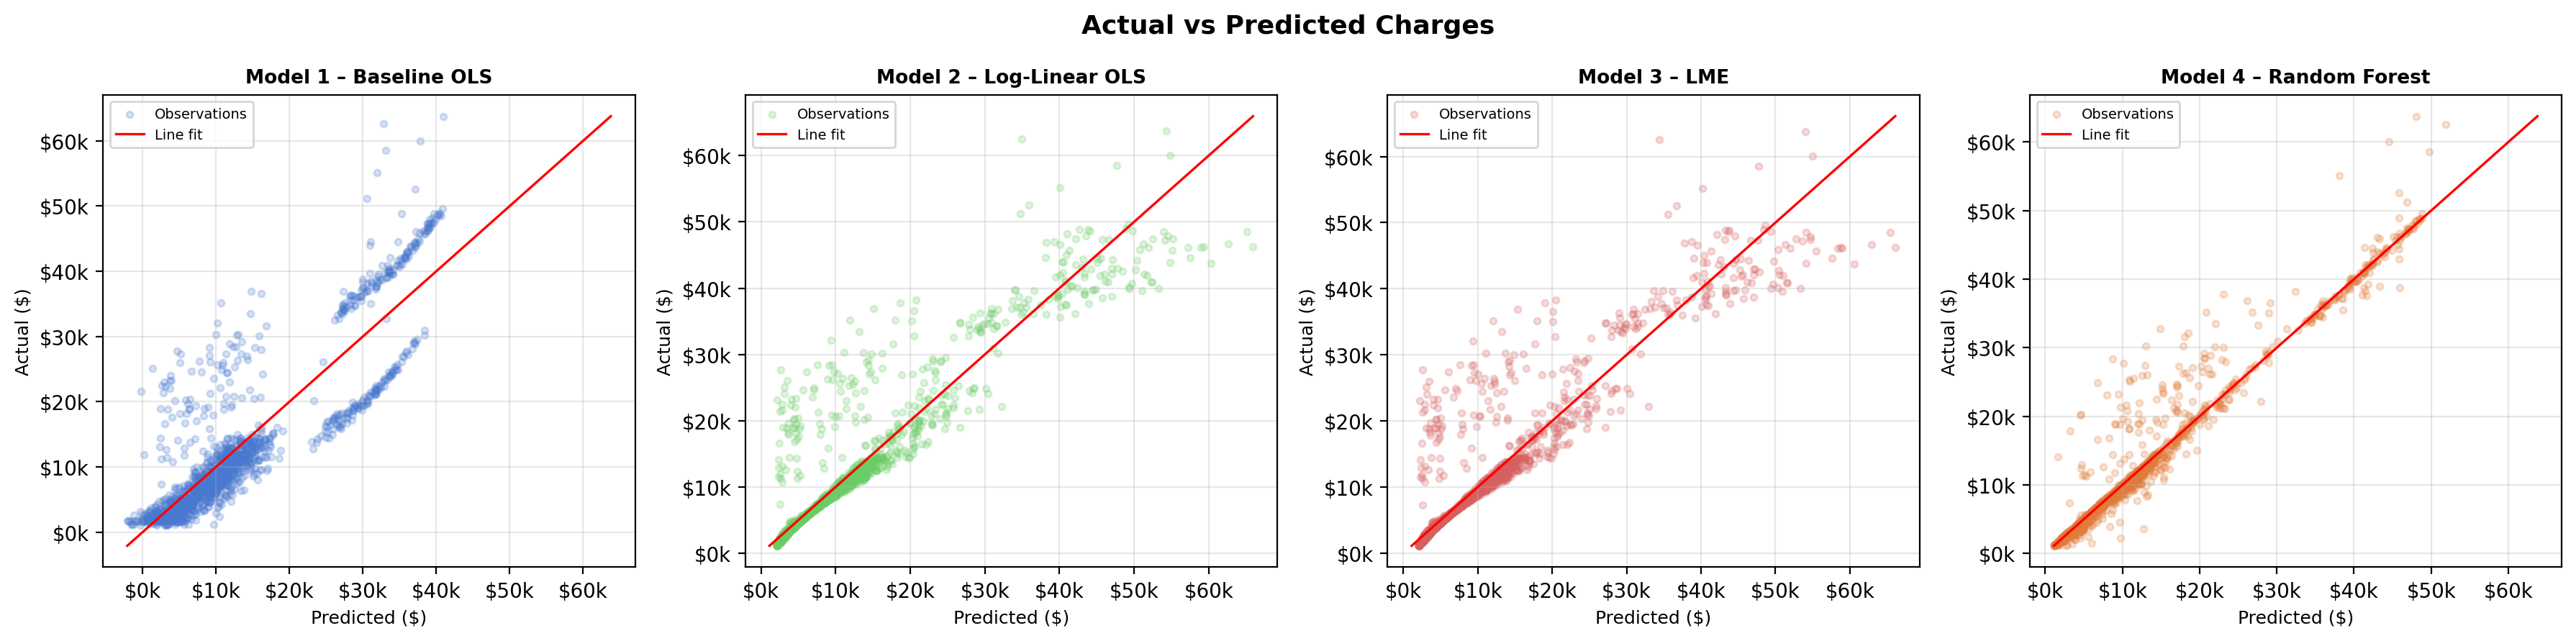

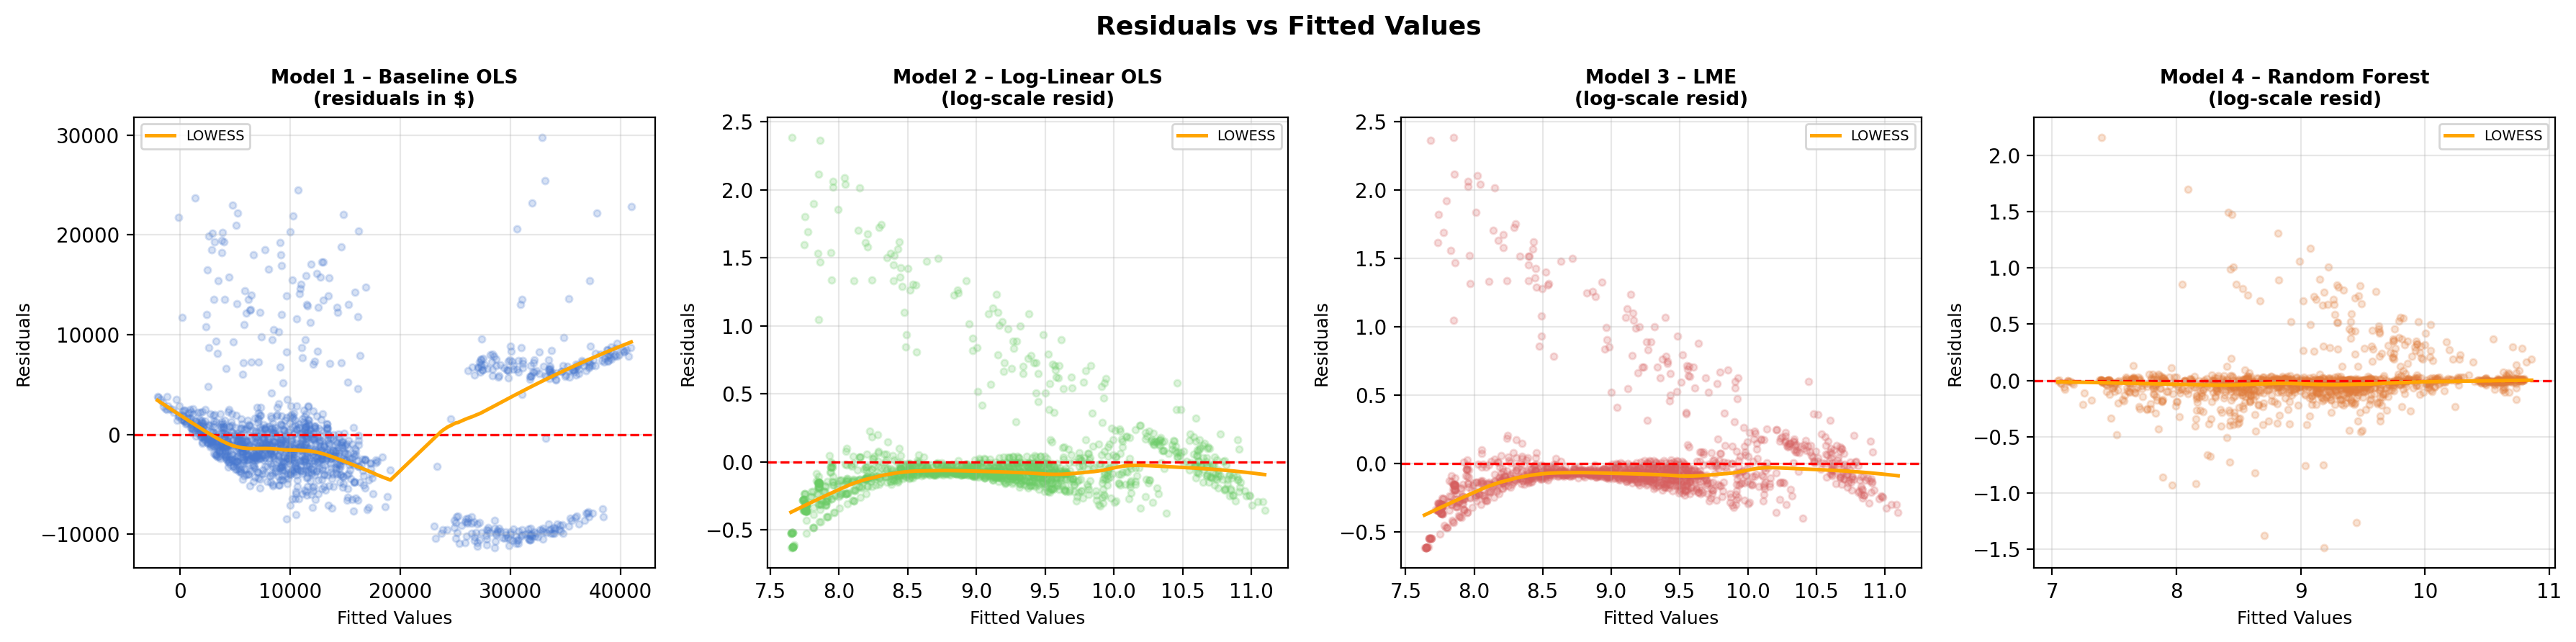

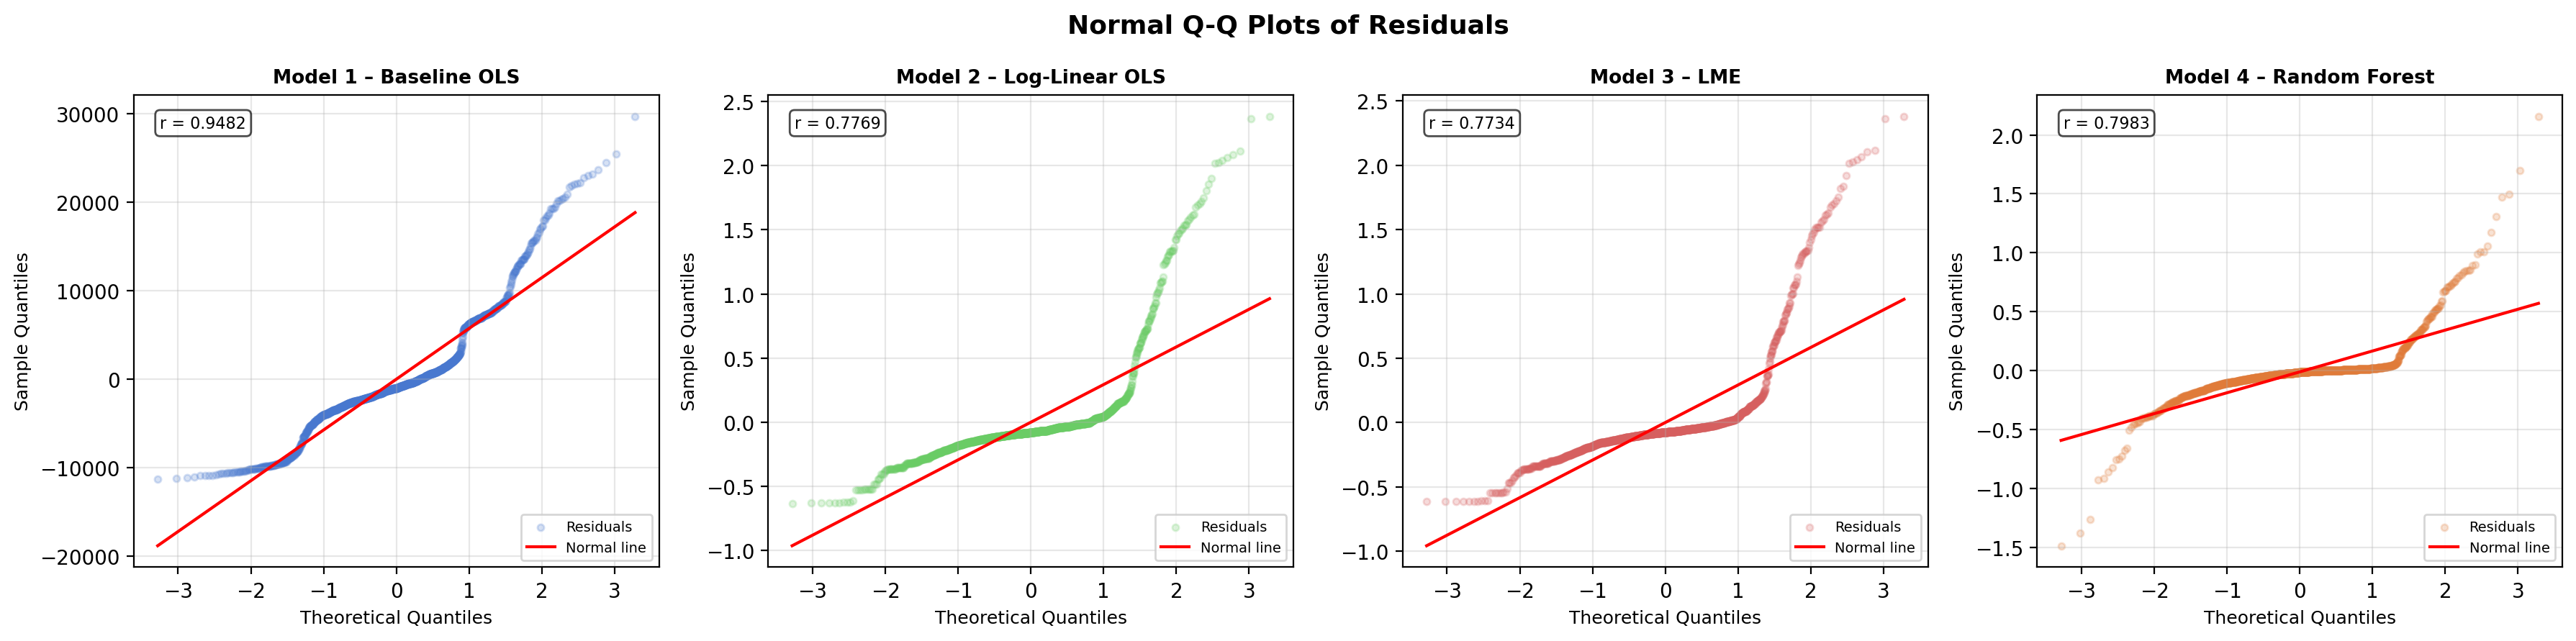

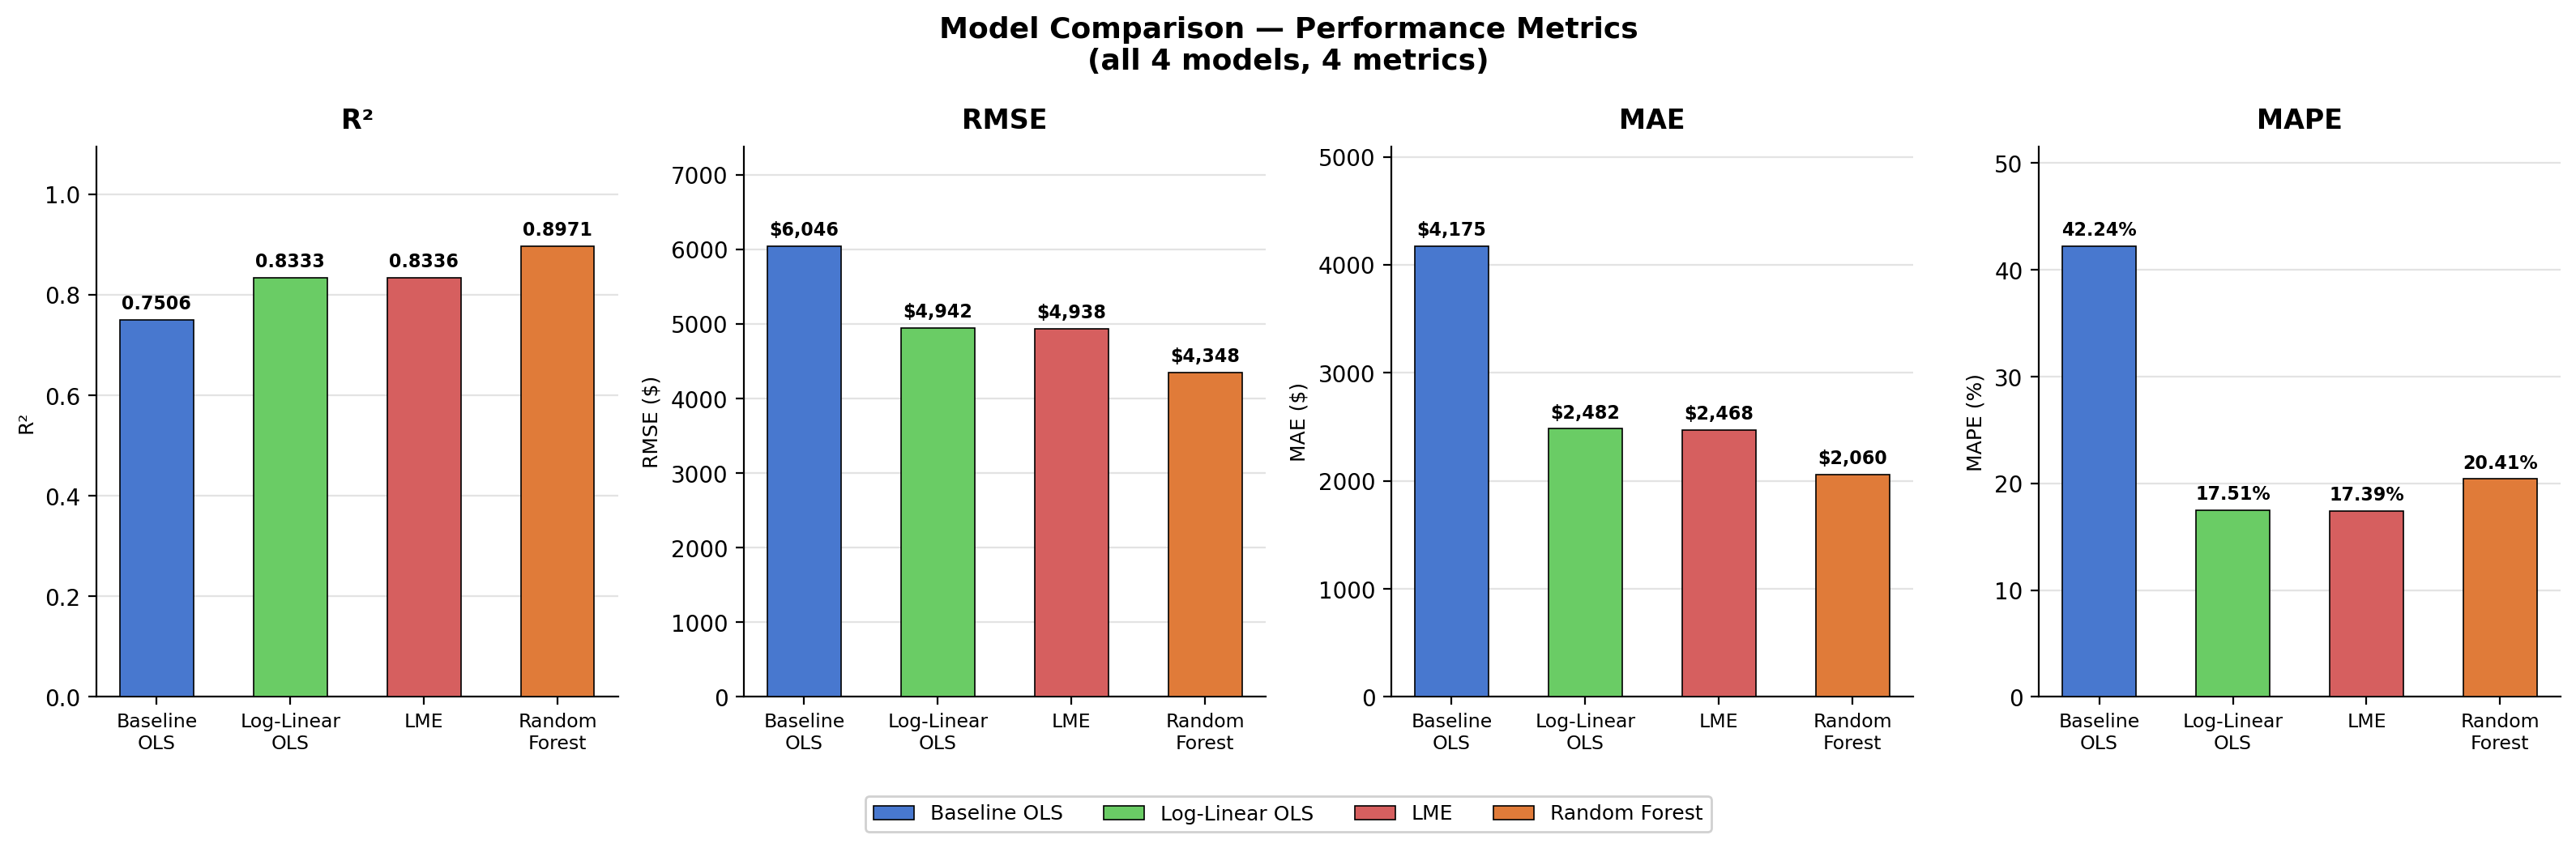

In [24]:
## TritonGPT code for creating plots from models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

y_raw  = df_final['charges'].values
y_log  = df_final['charges_log'].values

fit1= res1.fittedvalues.values          # dollar scale
fit2 = res2.fittedvalues.values          # log scale
fit3 = lme_result.fittedvalues.values    # log scale
fit4_log  = rf.predict(X)                     # log scale  (RF trained on log target)

fit2_raw  = np.exp(fit2)
fit3_raw  = np.exp(fit3)
fit4_raw  = np.exp(fit4_log)                  # dollar scale

resid1 = res1.resid.values                    # dollar scale
resid2 = res2.resid.values                    # log scale
resid3 = y_log - fit3                         # log scale
resid4 = y_log - fit4_log                     # log scale  (consistent with M2/M3)

rf_r2   = r2_score(y_raw, fit4_raw)
rf_rmse = np.sqrt(mean_squared_error(y_raw, fit4_raw))
rf_mae  = mean_absolute_error(y_raw, fit4_raw)
rf_mape = np.mean(np.abs((y_raw - fit4_raw) / y_raw)) * 100

print("RF in-sample metrics ($ scale):")
print(f"  R²   = {rf_r2:.4f}")
print(f"  RMSE = {rf_rmse:,.2f}")
print(f"  MAE  = {rf_mae:,.2f}")
print(f"  MAPE = {rf_mape:.2f}%")

# ── shared helpers ─────────────────────────────────────────────────────────────
def _ref_line(ax, x, y, color='red', lw=1.2):
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color=color, lw=lw, label='Line fit')

def _zero_line(ax, color='red', lw=1.2):
    ax.axhline(0, color=color, lw=lw, ls='--')

COLORS = ['#4878CF', '#6ACC65', '#D65F5F', '#E07B39']   # M1, M2, M3, RF
SCATTER_KW = dict(alpha=0.22, s=11)

# FIGURE 1 — Actual vs Predicted  (4 panels)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=False, dpi=200)
fig.suptitle('Actual vs Predicted Charges', fontsize=13, fontweight='bold')

avp_data = [
    (y_raw, fit1,     'Model 1 – Baseline OLS',    COLORS[0]),
    (y_raw, fit2_raw, 'Model 2 – Log-Linear OLS',  COLORS[1]),
    (y_raw, fit3_raw, 'Model 3 – LME',             COLORS[2]),
    (y_raw, fit4_raw, 'Model 4 – Random Forest',   COLORS[3]),
]

for ax, (ytrue, ypred, title, col) in zip(axes, avp_data):
    ax.scatter(ypred, ytrue, color=col, **SCATTER_KW, label='Observations')
    _ref_line(ax, ypred, ytrue)
    ax.set_xlabel('Predicted ($)', fontsize=9)
    ax.set_ylabel('Actual ($)', fontsize=9)
    ax.set_title(title, fontsize=9.5, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# FIGURE 2 — Residuals vs Fitted  (4 panels)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), dpi=200)
fig.suptitle('Residuals vs Fitted Values', fontsize=13, fontweight='bold')

rv_data = [
    (fit1,     resid1, 'Model 1 – Baseline OLS\n(residuals in $)',      COLORS[0]),
    (fit2,     resid2, 'Model 2 – Log-Linear OLS\n(log-scale resid)',   COLORS[1]),
    (fit3,     resid3, 'Model 3 – LME\n(log-scale resid)',              COLORS[2]),
    (fit4_log, resid4, 'Model 4 – Random Forest\n(log-scale resid)',    COLORS[3]),
]

for ax, (fitted, resid, title, col) in zip(axes, rv_data):
    ax.scatter(fitted, resid, color=col, **SCATTER_KW)
    _zero_line(ax)
    sm_fit = lowess(resid, fitted, frac=0.3)
    ax.plot(sm_fit[:, 0], sm_fit[:, 1], color='orange', lw=1.8, label='LOWESS')
    ax.set_xlabel('Fitted Values', fontsize=9)
    ax.set_ylabel('Residuals', fontsize=9)
    ax.set_title(title, fontsize=9.5, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# FIGURE 3 — Q-Q Plots  (4 panels)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), dpi=200)
fig.suptitle('Normal Q-Q Plots of Residuals', fontsize=13, fontweight='bold')

qq_data = [
    (resid1, 'Model 1 – Baseline OLS',   COLORS[0]),
    (resid2, 'Model 2 – Log-Linear OLS', COLORS[1]),
    (resid3, 'Model 3 – LME',            COLORS[2]),
    (resid4, 'Model 4 – Random Forest',  COLORS[3]),
]

for ax, (resid, title, col) in zip(axes, qq_data):
    (osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm')
    ax.scatter(osm, osr, color=col, **SCATTER_KW, label='Residuals')
    ax.plot(osm, slope * np.array(osm) + intercept, color='red', lw=1.5, label='Normal line')
    # annotate correlation coefficient
    ax.text(0.05, 0.93, f'r = {r:.4f}', transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    ax.set_xlabel('Theoretical Quantiles', fontsize=9)
    ax.set_ylabel('Sample Quantiles', fontsize=9)
    ax.set_title(title, fontsize=9.5, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# FIGURE 4 — Model Comparison: 4 subplots, one per metric (R², RMSE, MAE, MAPE)
model_labels = ['Baseline\nOLS', 'Log-Linear\nOLS', 'LME', 'Random\nForest']
model_colors = ['#4878CF', '#6ACC65', '#D65F5F', '#E07B39']

metrics_cfg = [
    # (title,  ylabel,    values,                                             fmt_fn,               higher_is_better)
    ('R²',   'R²',        [m1['R2'],   m2['R2'],   m3['R2'],   m4['R2']],   lambda v: f'{v:.4f}', True),
    ('RMSE', 'RMSE ($)',  [m1['RMSE'], m2['RMSE'], m3['RMSE'], m4['RMSE']], lambda v: f'${v:,.0f}', False),
    ('MAE',  'MAE ($)',   [m1['MAE'],  m2['MAE'],  m3['MAE'],  m4['MAE']],  lambda v: f'${v:,.0f}', False),
    ('MAPE', 'MAPE (%)',  [m1['MAPE'], m2['MAPE'], m3['MAPE'], m4['MAPE']], lambda v: f'{v:.2f}%',  False),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5), dpi=200)
fig.suptitle('Model Comparison — Performance Metrics\n(all 4 models, 4 metrics)',
             fontsize=13, fontweight='bold')

x = np.arange(len(model_labels))

for ax, (title, ylabel, values, fmt_fn, higher_better) in zip(axes, metrics_cfg):
    best_idx = int(np.argmax(values) if higher_better else np.argmin(values))

    bars = ax.bar(x, values, color=model_colors, edgecolor='black',
                  linewidth=0.6, width=0.55, zorder=3)

    # gold star on the best-performing bar
    best_bar = bars[best_idx]

    # value annotations on every bar
    y_pad = max(values) * 0.015
    for bar, v in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_pad,
            fmt_fn(v),
            ha='center', va='bottom', fontsize=8, fontweight='bold'
        )

    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, fontsize=8.5)
    ax.set_ylim(0, max(values) * 1.22)
    ax.grid(axis='y', alpha=0.35, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)

# shared legend for model colours
handles = [plt.Rectangle((0, 0), 1, 1, color=c, ec='black', lw=0.6)
           for c in model_colors]
fig.legend(handles, ['Baseline OLS', 'Log-Linear OLS', 'LME', 'Random Forest'],
           loc='lower center', ncol=4, fontsize=9, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [15]:
m3

{'R2': 0.8336151978825677,
 'RMSE': np.float64(4938.003504602906),
 'MAE': 2467.8948670621726,
 'MAPE': np.float64(17.393049681656244)}

Model 1 (Baseline OLS): $$\widehat{\text{charges}} = \beta_0 + \beta_1 \cdot \text{age} + \beta_2 \cdot \text{sex} + \beta_3 \cdot \text{bmi} + \beta_4 \cdot \text{children} + \beta_5 \cdot \text{smoker} + \beta_6 \cdot \text{region} + \varepsilon$$

Model 2 (Log-Linear OLS): $$\widehat{\ln(\text{charges})} = \beta_0 + \beta_1 \cdot \text{age} + \beta_2 \cdot \text{age}^2 + \beta_3 \cdot \text{sex} + \beta_4 \cdot \text{bmi} + \beta_5 \cdot \text{children} + \beta_6 \cdot \text{smoker} + \beta_7 \cdot \text{smoker\_bmi} + \beta_8 \cdot \text{smoker\_age} + \beta_9 \cdot \text{smoker\_obese} + \beta_{10} \cdot \text{obese} + \beta_{11} \cdot \text{region} + \varepsilon $$

Model 3 (Linear Mixed-Effects Model): $$\widehat{\ln(\text{charges})}_j = (\beta_0 + u_j) + \beta_1 \cdot \text{age} + \beta_2 \cdot \text{age}^2 + \beta_3 \cdot \text{sex} + \beta_4 \cdot \text{bmi} + \beta_5 \cdot \text{children} + \beta_6 \cdot \text{smoker} + \beta_7 \cdot \text{smoker\_bmi} + \beta_8 \cdot \text{smoker\_age} + \beta_9 \cdot \text{smoker\_obese} + \beta_{10} \cdot \text{obese} + \varepsilon_j$$
$$u_j \sim \mathcal{N}(0, \sigma^2_u) \quad \varepsilon_j \sim \mathcal{N}(0, \sigma^2_\varepsilon) \quad \text{Cov}(u_j, \varepsilon_j) = 0 \quad j \in \{0, 1, 2, 3\} \text{ (regions)}$$

Model 4 (Random Forests): $$ \hat{F}(x) = \frac{1}{B} \sum_{b=1}^B \hat{f}_b(x)$$


## Extra Code Below

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(X_scaled, columns=df.columns)

In [6]:
pca = PCA().fit(df_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(f"cumulative_variance:\n{cumulative_variance}")
var_val = 0.70
n_components = np.argmax(cumulative_variance >= var_val) + 1
print(f"Components needed for {int(var_val*100)}% variance: {n_components}")

cumulative_variance:
[0.26908318 0.43808152 0.58769008 0.7305458  0.86672736 0.98093644
 1.        ]
Components needed for 70% variance: 4


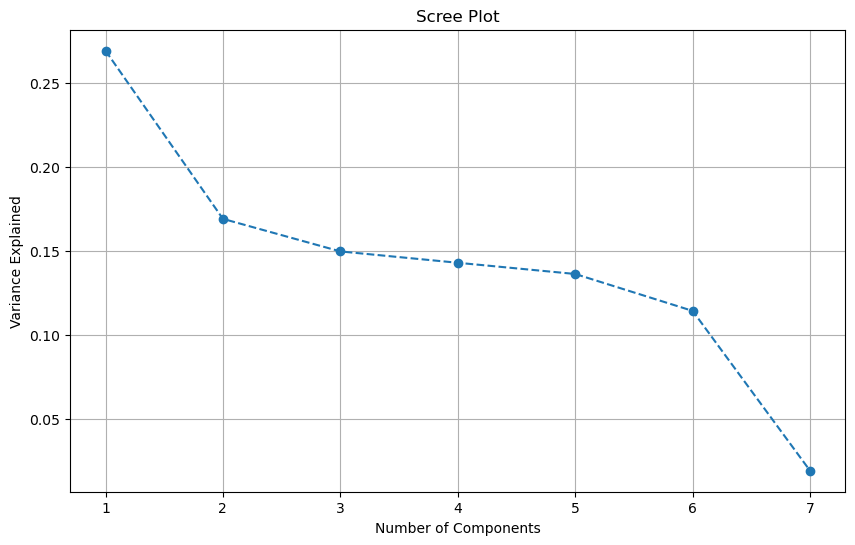

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 8), pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid()
plt.show()

In [8]:
s = df.corr()['charges'].sort_values()

In [9]:
print(s)

region     -0.006208
sex         0.057292
children    0.067998
bmi         0.198341
age         0.299008
smoker      0.787251
charges     1.000000
Name: charges, dtype: float64


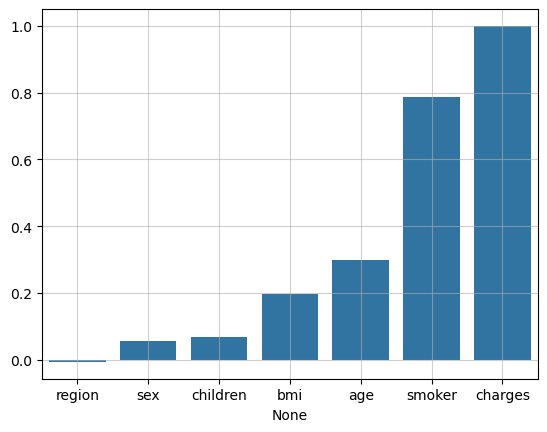

In [10]:
sns.barplot(x=s.index, y=s.values)
plt.grid(alpha=0.6)
plt.show()

<Axes: >

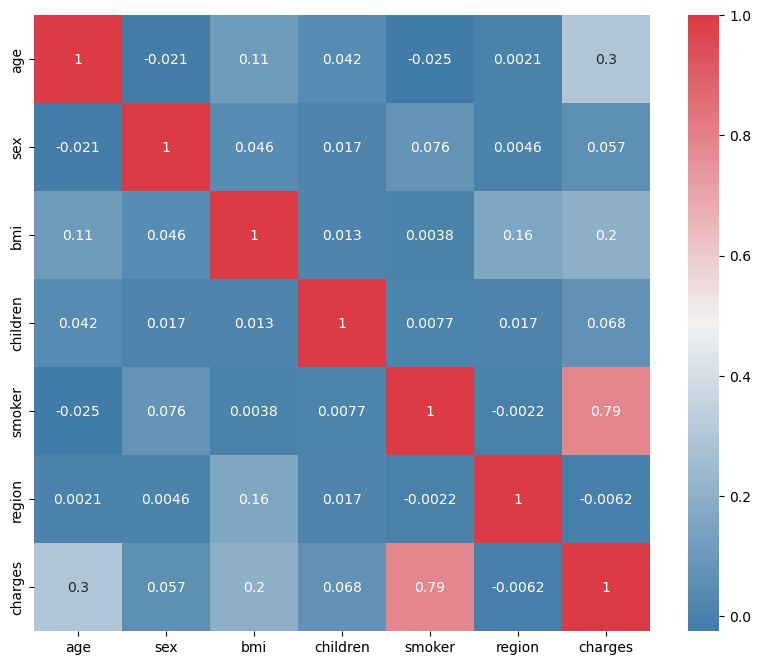

In [11]:
import seaborn as sns
f, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, mask=np.zeros_like(corr, dtype=np.bool), cmap=sns.diverging_palette(240,10,as_cmap=True), square=True, ax=ax)

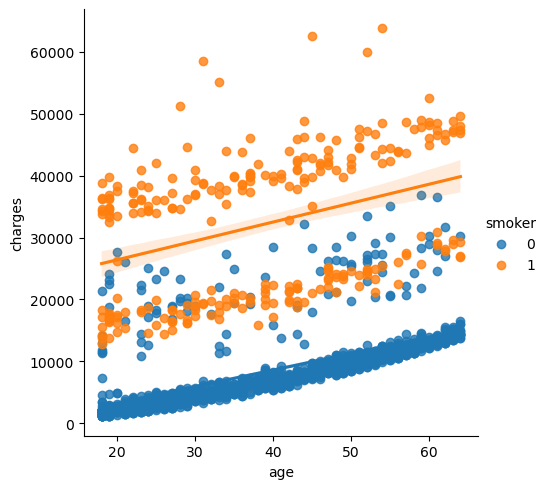

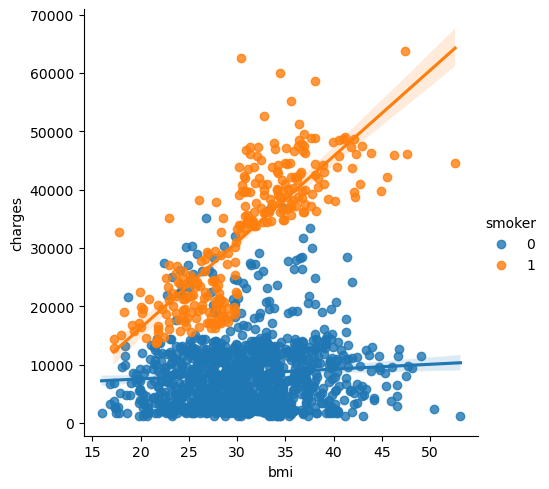

In [12]:
ax = sns.lmplot(x = 'age', y = 'charges', data=df, hue='smoker')
ax = sns.lmplot(x = 'bmi', y = 'charges', data=df, hue='smoker')

In [13]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [14]:
# df['age_smoker'] = df['age'] * df['smoker']
# df['bmi_smoker'] = df['bmi'] * df['smoker']

In [15]:
from sklearn.model_selection import train_test_split as holdout
from sklearn.linear_model import LinearRegression
from sklearn import metrics
x = df.drop(['charges','children', 'region', 'sex'], axis = 1)
y = df['charges']
x_train, x_test, y_train, y_test = holdout(x, y, test_size=0.2, random_state=0)
Lin_reg = LinearRegression()
Lin_reg.fit(x_train, y_train)
print(Lin_reg.intercept_)
print(Lin_reg.coef_)
print(Lin_reg.score(x_test, y_test))

-11571.908016839925
[  257.04066602   321.83997719 23625.23448834]
0.7945500805653087


In [16]:
x = df.drop(['charges', 'children', 'region', 'sex'], axis=1)
y = df['charges']
x_train, x_test, y_train, y_test = holdout(x, y, test_size=0.2, random_state=0)

mlp_reg = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=2500, random_state=0)
mlp_reg.fit(x_train, y_train)

y_pred = mlp_reg.predict(x_test)
print(f"R² Score:  {mlp_reg.score(x_test, y_test):.4f}")
print(f"MAE:       {metrics.mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE:      {np.sqrt(metrics.mean_squared_error(y_test, y_pred)):.2f}")

R² Score:  0.7966
MAE:       3828.14
RMSE:      5689.11


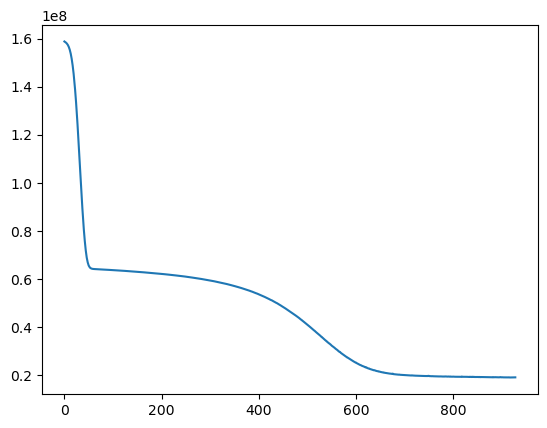

In [17]:
plt.plot(mlp_reg.loss_curve_)
plt.show()

In [18]:
from sklearn.preprocessing import PolynomialFeatures
x = df.drop(['charges', 'sex', 'region', 'children'], axis = 1)
y = df.charges
pol = PolynomialFeatures (degree = 2)
x_pol = pol.fit_transform(x)
x_train, x_test, y_train, y_test = holdout(x_pol, y, test_size=0.2, random_state=0)
Pol_reg = LinearRegression()
Pol_reg.fit(x_train, y_train)
y_train_pred = Pol_reg.predict(x_train)
y_test_pred = Pol_reg.predict(x_test)
print(Pol_reg.intercept_)
print(Pol_reg.coef_)
print(Pol_reg.score(x_test, y_test))

-6220.197801425229
[ 0.00000000e+00  7.03334822e+01  4.98130645e+02 -9.73998136e+03
  1.53678215e+00  2.40254198e+00  2.60895141e+00 -9.19302545e+00
  1.41047824e+03 -9.73998136e+03]
0.8773278585856426
